# Data Exploration

### Clean Dataset Provided by Josh

To Do list:
- Look at the UF pump operational strategy
- Plot PRO trains on for month of October and compare UF pump speeds / powers for 2, 3 and 4 PRO trains.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

### Loading Data for a Month

In [2]:
month = '10'
Data  = pd.read_csv("ARC_Unified_" + month + "2021.csv")
# Data = pd.read_csv("SolarData_2021-08-01.csv")
Data['dateTime']  = pd.to_datetime(Data['dateTime'])

print('-'*30)
print("Valid X and Y data value Choices")
print('-'*30)
for col in Data.columns:
    print(col)
print('-'*30)

------------------------------
Valid X and Y data value Choices
------------------------------
dateTime
PROS1_1_VFD
PROS1_1_SuctionPres_psi
PROS1_1_DischargePres_psi
PROS1_1_PermeateFlow_gpm
PROS1_1_RecoveryRate
PROS1_1_Temperature_degC
PROS1_1_FeedFlow_gpm
PROS1_1_FeedCond_uscm
PROS1_1_PermeateCond_uscm
PRO_1_Permeatepressure_psi
PRO_1_RecoverySP
PRO_1_OnIndicator
PROS2_1_VFD
PROS2_1_SuctionPres_psi
PROS2_1_DischargePres_psi
PROS2_1_PermeateFlow_gpm
PROS2_1_ConcentrateFlow_gpm
PROS2_1_RecoveryRate
PROS2_1_FeedFlow_gpm
PROS2_1_FeedConductivity_uscm
PROS2_1_PermeateConductivity_uscm
PRO_1_ConcentrateConductivity_uscm
PROS1_2_VFD
PROS1_2_SuctionPres_psi
PROS1_2_DischargePres_psi
PROS1_2_PermeateFlow_gpm
PROS1_2_RecoveryRate
PROS1_2_Temperature_degC
PROS1_2_FeedFlow_gpm
PROS1_2_FeedCond_uscm
PROS1_2_PermeateCond_uscm
PRO_2_Permeatepressure_psi
PRO_2_RecoverySP
PRO_2_OnIndicator
PROS2_2_VFD
PROS2_2_SuctionPres_psi
PROS2_2_DischargePres_psi
PROS2_2_PermeateFlow_gpm
PROS2_2_ConcentrateFlow_g

## Plotting a variable over one month

In [ ]:
# Define Variable to plot
# Extract first character as integer from Plant_ROConfig
# num_PRO_trains = Data['Plant_ROConfig'].astype(str).str[0].astype(int).values
# print(num_PRO_trains)

# Sum number of hours the flowrate is between like 

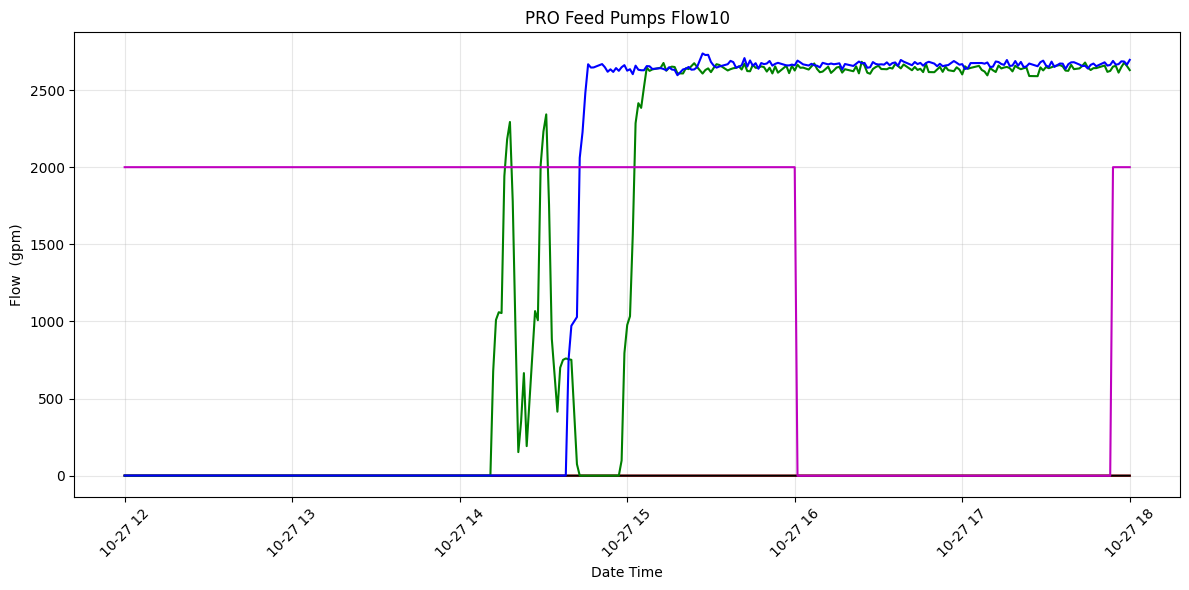

In [ ]:
# Plot num_PRO_trains over time 
# Use datetime range: 2021-10-24 01:00 to 2021-10-31 00:00
start_date = pd.Timestamp('2021-10-27 12:00')
end_date = pd.Timestamp('2021-10-27 18:00')
mask = (Data['dateTime'] >= start_date) & (Data['dateTime'] <= end_date)

plt.figure(figsize=(12, 6))
# For August, 11000:12000 is the shutdown event, for October, 13500:14500 is the shutdown event
plt.plot(Data.loc[mask, 'dateTime'], Data.loc[mask, 'PROS1_1_FeedFlow_gpm'],'r-', markersize=3)
plt.plot(Data.loc[mask, 'dateTime'], Data.loc[mask, 'PROS1_2_FeedFlow_gpm'],'k-', markersize=3)
plt.plot(Data.loc[mask, 'dateTime'], Data.loc[mask, 'PROS1_3_FeedFlow_gpm'],'g-', markersize=3)
plt.plot(Data.loc[mask, 'dateTime'], Data.loc[mask, 'PROS1_4_FeedFlow_gpm'],'b-', markersize=3)
plt.plot(Data.loc[mask, 'dateTime'], 2000 * Data.loc[mask, 'Off-Spec_OpenRecycleValve'],'m-', markersize=3)

# plt.plot(Data['dateTime'][11000:13000], Data['PROS1_1_PermeateFlow_gpm'][11000:13000],'r--', markersize=3)
# plt.plot(Data['dateTime'][11000:13000], Data['PROS1_2_PermeateFlow_gpm'][11000:13000],'k--', markersize=3)
# plt.plot(Data['dateTime'][11000:13000], Data['PROS1_3_PermeateFlow_gpm'][11000:13000],'g--', markersize=3)

# plt.plot(Data['dateTime'][2:], Data['TSRO_1_SuctionPres_psi'][2:],'o-', markersize=3)
# plt.plot(Data['dateTime'][2:], Data['TSRO_2_SuctionPres_psi'][2:],'o-', markersize=3)
# plt.plot(Data['dateTime'][2:], Data['TSRO_3_SuctionPres_psi'][2:],'p-', markersize=3)

plt.xlabel('Date Time')
plt.ylabel('Flow  (gpm)')
# plt.title('PRO Train Configuration Over Time - Month ' + month)
plt.title('PRO Feed Pumps Flow' + month)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Plot num_PRO_trains over time
plt.figure(figsize=(12, 6))
# For August, 11000:12000 is the shutdown event, for October, 13500:14500 is the shutdown event
plt.plot(Data['dateTime'][11000:12000], Data['Plant_PWFlowtoMFSG_MGD'][11000:12000],'r-', markersize=3, label='Plant Product Water')
plt.plot(Data['dateTime'][11000:12000], Data['Plant_FeedFlow'][11000:12000]*(24*60/10**6),'k-', markersize=3, label='Plant Feed Flow')
# plt.plot(Data['dateTime'][2:], Data['PROS1_2_kW'][2:],'k-', markersize=3)
# plt.plot(Data['dateTime'][2:], Data['PROS1_3_kW'][2:],'g-', markersize=3)
# plt.plot(Data['dateTime'][2:], Data['PROS1_4_kW'][2:],'b-', markersize=3)
# plt.plot(Data['dateTime'][2:], Data['TSRO_1_kW'][2:],'o-', markersize=3)
# plt.plot(Data['dateTime'][2:], Data['TSRO_2_kW'][2:],'p-', markersize=3)
# plt.plot(Data['dateTime'][2:], Data['TSRO_3_kW'][2:],'p-', markersize=3)
# plt.plot(Data['dateTime'][2:], Data['TSRO_4_kW'][2:],'p-', markersize=3)
plt.xlabel('Date Time')
plt.ylabel('Plant Product Water (MGD)')
plt.title('Example Shutdown Event')
# plt.title('Plant Product Water - Month ' + month)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('Example Shutdown Event.png', dpi=300)

In [ ]:
# Plot for the energy consumption of the plant
plt.figure(figsize=(12, 6))
plt.plot(Data['dateTime'][11000:12000], Data['Plant_TotalPowerDemand_kW'][11000:12000],'r-', markersize=3, label='Plant Total Energy')
plt.plot(Data['dateTime'][11000:12000], Data['On-Spec_ClosedRecycleValve'][11000:12000]*1000,'g-', markersize=3, label='On-Spec Closed Recycle Valve')
# plt.plot(Data['dateTime'][13500:14500], Data['Off-Spec_OpenRecycleValve'][13500:14500],'b-', markersize=3, label='Off-Spec Open Recycle Valve')
plt.xlabel('Date Time')
plt.ylabel('Power (kW)')
plt.title('Plant Power Consumption')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

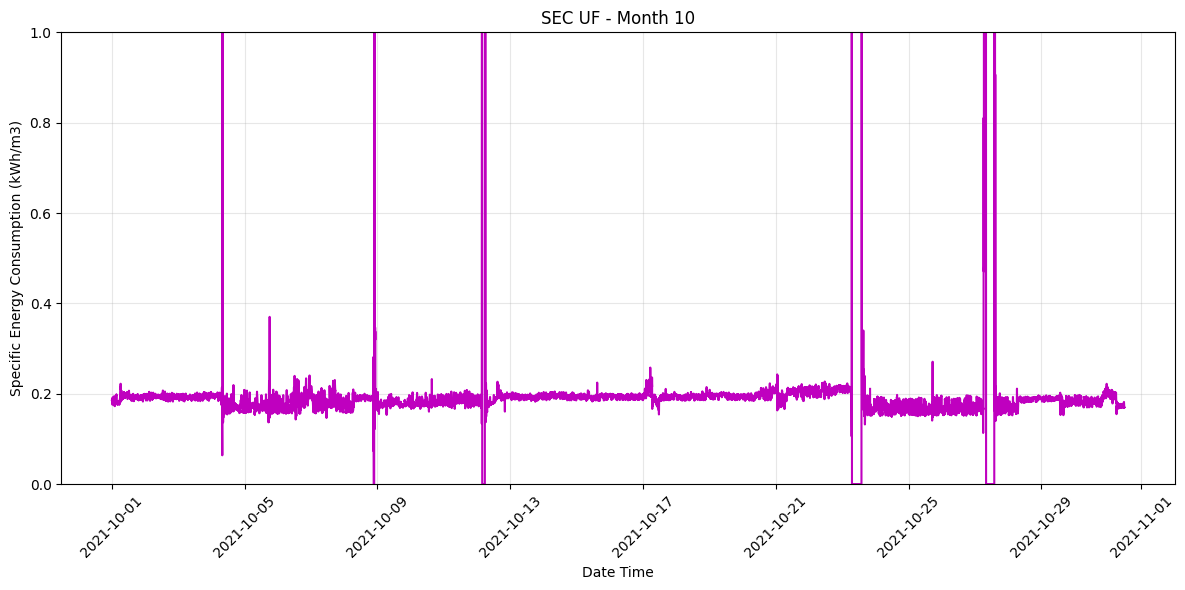

In [3]:
# Plot the specific energy consumption of the UF system over time
# Calc values
Data['UF_Power_kW'] = Data['UFFeedPumps_1_kW'] + Data['UFFeedPumps_2_kW'] + Data['UFFeedPumps_3_kW'] + Data['UFFeedPumps_4_kW']
Data['UF_Flow_m3_per_hr'] = (Data['PROS1_1_FeedFlow_gpm'] + Data['PROS1_2_FeedFlow_gpm'] + Data['PROS1_3_FeedFlow_gpm'] + Data['PROS1_4_FeedFlow_gpm']) / 264.2 * 60
Data['UF_SpecificEnergy_kWh_per_m3'] = (Data['UF_Power_kW']) / (Data['UF_Flow_m3_per_hr'])
# Plot
plt.figure(figsize=(12, 6))
plt.plot(Data['dateTime'][2:], Data['UF_SpecificEnergy_kWh_per_m3'][2:],'m-', markersize=3)
plt.xlabel('Date Time')
plt.ylabel('Specific Energy Consumption (kWh/m3)')
plt.ylim(0, 1)  # Set y-axis limits for better visualization
plt.title('SEC UF - Month ' + month)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# print(Data['UF_Power_kW'])
# print(Data['PROS1_1_FeedFlow_gpm'])
# print(Data['UF_SpecificEnergy_kWh_per_m3'])


In [ ]:
Data['Perm_1'] = Data['PROS1_1_PermeateFlow_gpm'] + Data['PROS2_1_PermeateFlow_gpm']
Data['RR_1'] = Data['Perm_1'] / Data['PROS1_1_FeedFlow_gpm']
Data['RR_S3_1']= Data['TSRO_1_PermeateFlow_gpm'] / Data['TSRO_1_FeedFlow_gpm']
# Plot
plt.figure(figsize=(12, 6))
plt.plot(Data['dateTime'][2:], Data['RR_1'][2:],'m-', markersize=3)
plt.xlabel('Date Time')
plt.ylabel('PRO Recovery Ratio')
plt.ylim(0, 1)  # Set y-axis limits for better visualization
plt.title('Recovery Ratio - Month ' + month)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(Data['RR_1'][2:20])
print(Data['Perm_1'][2:20])

2800.649902
Number of low flow hours for train 1: 319
Number of very low flow hours for train 1: 314
Number of low flow hours for train 2: 162
Number of very low flow hours for train 2: 158
Number of low flow hours for train 3: 88
Number of very low flow hours for train 3: 83
Number of low flow hours for train 4: 85
Number of very low flow hours for train 4: 79
               dateTime  train_1_on  train_2_on  train_3_on  train_4_on  \
188 2021-10-08 20:00:00           1           1           1           1   
189 2021-10-08 21:00:00           0           0           0           0   
190 2021-10-08 22:00:00           0           1           1           0   
191 2021-10-08 23:00:00           1           1           1           1   
192 2021-10-09 00:00:00           0           1           1           1   
193 2021-10-09 01:00:00           0           1           1           1   
194 2021-10-09 02:00:00           0           1           1           1   
195 2021-10-09 03:00:00           0 

C:\Users\rchurchi\AppData\Local\Temp\1\ipykernel_18336\3350223111.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = Data.set_index('dateTime')[['train_1_on', 'train_2_on', 'train_3_on', 'train_4_on', 'train_1_flow_pct','train_2_flow_pct','train_3_flow_pct','train_4_flow_pct']].resample('H').mean()


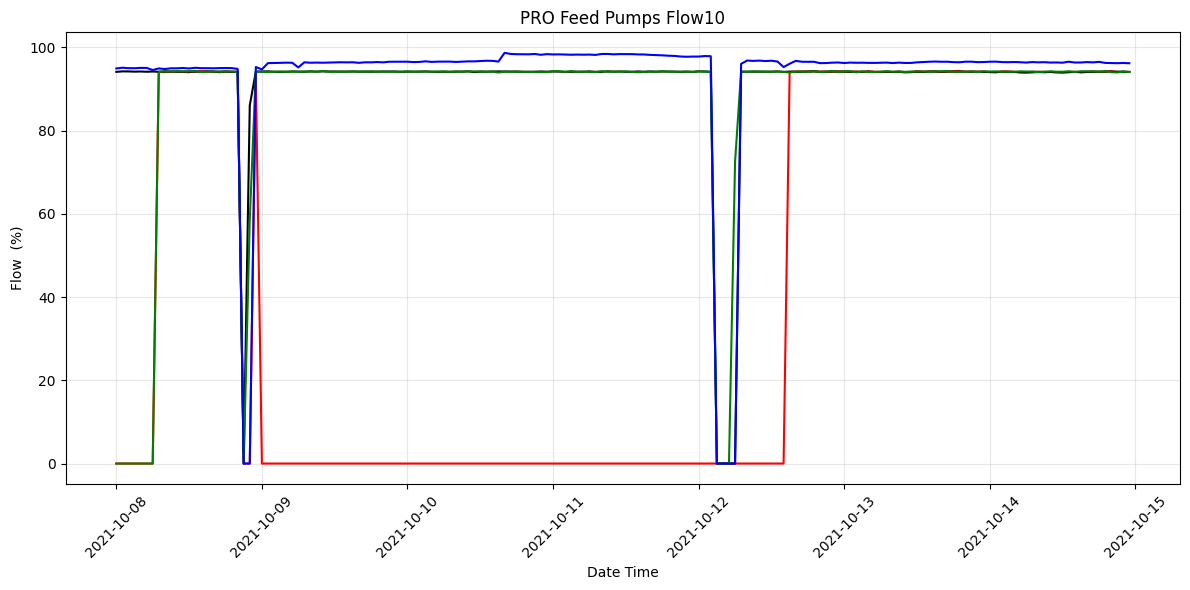

In [18]:
# Creating a file for the operation of the RO during one month
Data['train_1_on'] = (Data['PROS1_1_kW'] > 100).astype(int)
Data['train_2_on'] = (Data['PROS1_2_kW'] > 100).astype(int)
Data['train_3_on'] = (Data['PROS1_3_kW'] > 100).astype(int)
Data['train_4_on'] = (Data['PROS1_4_kW'] > 100).astype(int)

max_flow = Data['PROS1_3_FeedFlow_gpm'][2:].max()
Data['train_1_flow_pct'] = Data['PROS1_1_FeedFlow_gpm'] / max_flow * 100
Data['train_2_flow_pct'] = Data['PROS1_2_FeedFlow_gpm'] / max_flow * 100
Data['train_3_flow_pct'] = Data['PROS1_3_FeedFlow_gpm'] / max_flow * 100
Data['train_4_flow_pct'] = Data['PROS1_4_FeedFlow_gpm'] / max_flow * 100
print(max_flow)

# Change to hourly average
hourly_data = Data.set_index('dateTime')[['train_1_on', 'train_2_on', 'train_3_on', 'train_4_on', 'train_1_flow_pct','train_2_flow_pct','train_3_flow_pct','train_4_flow_pct']].resample('H').mean()

# Cap flow_pct values at 100
for i in [1, 2, 3, 4]:
    hourly_data[f'train_{i}_flow_pct'] = hourly_data[f'train_{i}_flow_pct'].clip(upper=100)

# Apply threshold to train_on columns: >0.5 rounds to 1
for col in ['train_1_on', 'train_2_on', 'train_3_on', 'train_4_on']:
    hourly_data[col] = (hourly_data[col] > 0.5).astype(int)

# Set flow_pct to 0 when train is off
for i in [1, 2, 3, 4]:
    hourly_data.loc[hourly_data[f'train_{i}_on'] == 0, f'train_{i}_flow_pct'] = 0

# Set both flow_pct and train_on to 0 when flow_pct < 85%

for i in [1, 2, 3, 4]:
    low_flow_mask = hourly_data[f'train_{i}_flow_pct'] < 85
    very_low_flow_mask = hourly_data[f'train_{i}_flow_pct'] < 10
    print(f"Number of low flow hours for train {i}: {sum(low_flow_mask)}")
    print(f"Number of very low flow hours for train {i}: {sum(very_low_flow_mask)}")
    # hourly_data.loc[low_flow_mask, f'train_{i}_flow_pct'] = 0
    # hourly_data.loc[low_flow_mask, f'train_{i}_on'] = 0

# Drop first row (outlier) and create DataFrame
JKM_model_data = hourly_data.reset_index().iloc[1:]


# Plot num_PRO_trains over time 
plt.figure(figsize=(12, 6))
start_date = pd.Timestamp('2021-10-08 00:00:00')
end_date = pd.Timestamp('2021-10-14 23:59:59')
mask = (JKM_model_data['dateTime'] >= start_date) & (JKM_model_data['dateTime'] <= end_date)
plt.plot(JKM_model_data['dateTime'][mask], JKM_model_data['train_1_flow_pct'][mask],'r-', markersize=3)
plt.plot(JKM_model_data['dateTime'][mask], JKM_model_data['train_2_flow_pct'][mask],'k-', markersize=3)
plt.plot(JKM_model_data['dateTime'][mask], JKM_model_data['train_3_flow_pct'][mask],'g-', markersize=3)
plt.plot(JKM_model_data['dateTime'][mask], JKM_model_data['train_4_flow_pct'][mask],'b-', markersize=3)
print(JKM_model_data[mask][20:30])
# plt.plot(Data['dateTime'][11000:13000], Data['PROS1_1_PermeateFlow_gpm'][11000:13000],'r--', markersize=3)
# plt.plot(Data['dateTime'][11000:13000], Data['PROS1_2_PermeateFlow_gpm'][11000:13000],'k--', markersize=3)
# plt.plot(Data['dateTime'][11000:13000], Data['PROS1_3_PermeateFlow_gpm'][11000:13000],'g--', markersize=3)

# plt.plot(Data['dateTime'][2:], Data['TSRO_1_SuctionPres_psi'][2:],'o-', markersize=3)
# plt.plot(Data['dateTime'][2:], Data['TSRO_2_SuctionPres_psi'][2:],'o-', markersize=3)
# plt.plot(Data['dateTime'][2:], Data['TSRO_3_SuctionPres_psi'][2:],'p-', markersize=3)

plt.xlabel('Date Time')
plt.ylabel('Flow  (%)')
# plt.title('PRO Train Configuration Over Time - Month ' + month)
plt.title('PRO Feed Pumps Flow' + month)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Save to CSV
JKM_model_data.to_csv('JKM_model_data_month_' + month + '.csv', index=False)

JKM_week_kW = JKM_model_data[(JKM_model_data['dateTime'] >= start_date) & (JKM_model_data['dateTime'] <= end_date)]
if len(JKM_week_kW) != 168:
    print(f"Warning: The length of the week data is {len(JKM_week_kW)} hours. Expected 168 hours. Check the indices.")
    raise ValueError("The length of the week data is not 168 hours. Check the indices.")
JKM_week_kW.to_csv('JKM_kW_week.csv', index=False)

In [ ]:
# Creating a different file for the hourly electricity consumption
cols = [col for col in Data.columns if col.endswith('_kW')]
print(cols)

hourly_powers = Data.set_index('dateTime')[cols].resample('h').mean()
print(hourly_powers[90:100])
total_kW = hourly_powers.sum(axis=1) - hourly_powers['Plant_TotalPowerDemand_kW'] #- hourly_powers['UF_Power_kW'] #- hourly_powers['Solar_GrossGeneration_kW'] 
print(total_kW[90:100])

# Export as two columns: dateTime and total power
total_power_data = total_kW.rename('TotalPower_kW')
print(total_power_data.head())
total_power_data.to_csv('Oct_21_kW.csv', index=True, index_label='dateTime')

# Oct_21_hourly_kW = hourly_powers.reset_index().iloc[1:]
# Oct_21_kW = Oct_21_hourly_kW.sum()
# if len(Oct_21_week_kW) != 168:
#     print(f"Warning: The length of the week data is {len(Oct_21_week_kW)} hours. Expected 168 hours. Check the indices.")
#     raise ValueError("The length of the week data is not 168 hours. Check the indices.")
# Oct_21_kW.to_csv('Oct_21_kW_.csv', index=False)

['UFFeedPumps_1_kW', 'UFFeedPumps_2_kW', 'UFFeedPumps_3_kW', 'UFFeedPumps_4_kW', 'Autostrainers_1_kW', 'Autostrainers_2_kW', 'Autostrainers_3_kW', 'Autostrainers_4_kW', 'PROS1_1_kW', 'PROS1_2_kW', 'PROS1_3_kW', 'PROS1_4_kW', 'PROS2_1_kW', 'PROS2_2_kW', 'PROS2_3_kW', 'PROS2_4_kW', 'TSRO_1_kW', 'TSRO_2_kW', 'TSRO_3_kW', 'TSRO_4_kW', 'UVAOP_1_kW', 'UVAOP_2_kW', 'Decarbonator_1_kW', 'Decarbonator_2_kW', 'Plant_TotalPowerDemand_kW', 'UF_Power_kW']
                     UFFeedPumps_1_kW  UFFeedPumps_2_kW  UFFeedPumps_3_kW  \
dateTime                                                                    
2021-10-04 18:00:00         95.948206               0.0        107.130662   
2021-10-04 19:00:00         93.232228               0.0        107.268554   
2021-10-04 20:00:00         90.825344               0.0        107.025033   
2021-10-04 21:00:00        112.138596               0.0        106.321925   
2021-10-04 22:00:00         98.188991               0.0        106.886661   
2021-10-04 23:

In [ ]:
# Create file with the breakdown of the power consumption by each component
hourly_powers.to_csv("hourly_powers_breakdown.csv")
print(max())

In [ ]:
# Creating hourly profile of the electricity production from PV
Data = pd.read_csv("SolarData_2021-03-01.csv")
Data['DateTime']  = pd.to_datetime(Data['DateTime'])

print('-'*30)
print("Valid X and Y data value Choices")
print('-'*30)
for col in Data.columns:
    print(col)
print('-'*30)
# Change to hourly average
hourly_data = Data.set_index('DateTime')[['GRIP_5001_SWBD_0301_ActivePwrTotal']].resample('H').mean()
print(hourly_data.head())
hourly_data.to_csv('March_21_PV_kW_hourly.csv', index=True)

### Pairing down data to a day

In [ ]:
#User Input
# ONE PRO TRAIN = '2021-06-14-00:00:00', deltatime = timedelta(days=1)
# TWO PRO TRAINS = '2021-06-28-00:00:00', deltatime = timedelta(days=1) or '2021-10-25-12:00:00', deltatime = timedelta(days=1)
# THREE PRO TRAINS: '2021-06-02-14:00:00' deltatime = timedelta(hours=12) or '2021-10-10-12:00:00' 
# FOUR PRO TRAINS: '2021-06-20-12:00:00' deltatime = timedelta(days=1)

day = '2021-06-20-12:00:00'
deltatime = timedelta(hours=12)
variables = ['PROS2_3_DischargePres_psi','TSRO_3_SuctionPres_psi','TSRO_1_kW','TSRO_2_kW','TSRO_3_kW','TSRO_4_kW','TSRO_1_PermeateFlow_gpm','TSRO_3_PermeateFlow_gpm','TSRO_1_FeedFlow_gpm','TSRO_3_FeedFlow_gpm']
# variables =['UFPump_1_VFDSpeed','UFPump_2_VFDSpeed','UFPump_3_VFDSpeed','UFPump_4_VFDSpeed','UF_SpecificEnergy_kWh_per_m3','UF_Power_kW']
# Find values
date_stamp = datetime.strptime(day, "%Y-%m-%d-%H:%M:%S")
mask = Data['dateTime'].between(date_stamp, date_stamp + deltatime)
day_df = Data.loc[mask].copy()

# Drop columns with a DataTime Formate
day_df.drop(columns=['UF2_LastBW_datetime','UF2_LastCIP_datetime','UF2_LastCEB_datetime','Plant_ROConfig'], inplace=True)

# Convert columns 1: to numeric safely
cols_to_convert = day_df.columns[1:-1] # First col is dateTime, last col is Plant config (4x4, 3x3, etc.)
day_df.loc[:, cols_to_convert] = day_df.loc[:, cols_to_convert].apply(pd.to_numeric)

for name in variables:
    mean = day_df.loc[:, name].mean()
    print("\nAverage value of " + name + " on " + day)
    print(mean)
    print('-' * 40)
    # print(day_df.loc[:, name])
    
print('-' * 40)
# print(day_df['Plant_ROConfig'])

# Plotting

In [ ]:
# User input to define x and y data
plot_title = "UF Power and Total Product Flow"
x_data_name = "dateTime"
y_data_name_list = ['PROS2_3_DischargePres_psi','TSRO_3_SuctionPres_psi']
# y_data_name_list = ["UF_SEC"]
yy_data_name_list = []

# Derived quantities
# day_df["UF_SEC"] = (1/60)*(day_df["UFFeedPumps_1_kW"] + day_df["UFFeedPumps_2_kW"] + day_df["UFFeedPumps_3_kW"] + day_df["UFFeedPumps_4_kW"]) / (day_df["Plant_PWFlowtoMFSG_MGD"]*24*60*264.2/1e6)
# print(day_df[["dateTime", "UF_SEC"]])

In [ ]:
# Create Plot
fig, ax1 = plt.subplots()

x_data = day_df[x_data_name]

# Plot first y-axis data
for y_data_name in y_data_name_list:
    y_data = day_df[y_data_name]
    ax1.plot(x_data, y_data, 'o', label=y_data_name)

ax1.set_xlabel(x_data_name)
ax1.set_ylabel("Pressure (psi)", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=45)
# ax1.set_ylim([1,1.5])
# Create second y-axis
ax2 = ax1.twinx()

# Plot second y-axis data
for yy_data_name in yy_data_name_list:
    yy_data = day_df[yy_data_name]
    ax2.plot(x_data, yy_data, 's', label=yy_data_name, color='black')

ax2.set_ylabel("Pressure (psi)", color='black')
ax2.tick_params(axis='y', labelcolor='black')

plt.title(plot_title + ": " + day)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

# Adjust Axes as needed
# plt.xlim(1400,2700)
# ax1.set_ylim(10,15)
# ax2.set_ylim(0, 20)

# Export Figure
# plt.savefig(plot_title+".png")

plt.tight_layout()

In [ ]:
# User input to define x and y data
plot_title = "PRO Feed Flowrates"
x_data_name = "dateTime"
y_data_name_list = ['PROS1_1_FeedFlow_gpm', 'PROS1_2_FeedFlow_gpm', 'PROS1_3_FeedFlow_gpm', 'PROS1_4_FeedFlow_gpm']
# y_data_name_list = ['PROS1_1_FeedCond_uscm','PROS1_2_FeedCond_uscm']
yy_data_name_list = []

# Derived quantities


In [ ]:
# Create Plot
fig, ax1 = plt.subplots()

x_data = day_df[x_data_name]

# Plot first y-axis data
for y_data_name in y_data_name_list:
    y_data = day_df[y_data_name]
    ax1.plot(x_data, y_data, 'o', label=y_data_name)

ax1.set_xlabel(x_data_name)
ax1.set_ylabel("Flowrate (gpm)")
ax1.tick_params(axis='y', labelcolor='black')
ax1.tick_params(axis='x', rotation=45)

plt.title(plot_title + ": " + day)
ax1.legend(loc='best')

#Adjust Axes as needed
# plt.xlim(1400,2700)
# ax1.set_ylim(10,15)
# ax2.set_ylim(0, 20)

#Export Figure
# plt.savefig(plot_title+".png")

plt.tight_layout()